# Titanic Survival Classification Report

## Introduction

The Titanic dataset is one of the most well-known binary classification problems in machine learning, originally based on real passenger records from the RMS Titanic disaster of 1912.  
This project aims to predict whether a passenger survived or not using features such as age, gender, passenger class, fare, and family size.  

The workflow followed in this notebook includes:
1. Loading and inspecting the dataset
2. Cleaning the data (handling missing values, dropping irrelevant columns)
3. Performing Exploratory Data Analysis (EDA) to understand patterns in survival
4. Encoding categorical features for modeling
5. Training a Logistic Regression model
6. Evaluating the model using accuracy, a confusion matrix, and a classification report


In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [2]:
# Load the dataset

df = pd.read_csv("train.csv")

In [3]:
# Display the first few rows of the dataset

df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
153,154,0,3,"van Billiard, Mr. Austin Blyler",male,40.5,0,2,A/5. 851,14.5000,NaN,S
240,241,0,3,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C
63,64,0,3,"Skoog, Master. Harald",male,4.0,3,2,347088,27.9000,NaN,S
643,644,1,3,"Foo, Mr. Choong",male,NaN,0,0,1601,56.4958,NaN,S
601,602,0,3,"Slabenoff, Mr. Petco",male,NaN,0,0,349214,7.8958,NaN,S


In [4]:
# checking columns and rows
df.shape

(891, 12)

The dataset contains 891 rows and 12 columns.

In [5]:
# checking columns
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [6]:
# checking data types and non-null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [7]:
# checking Statistical Summary
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
# checking null values
df.isnull().sum()   

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

There are 177 missing values in the **Age** column, 687 missing values in the **Cabin** column, and 2 missing values in the **Embarked** column.

Cabin has missing data for more than 75% of the records, which makes it unreliable to use for modeling, so it will be dropped rather than imputed.

# Data Cleaning

### Handling Missing Values
We fill the missing **Age** values using the mean of the column and the missing **Embarked** values using the mode (most frequent value), since these are reasonable estimates for a small number of missing entries. The **Cabin** column has too many missing values to be useful, so it is dropped entirely.

In [9]:
# Fill missing values with the mean of the column
df["Age"] = df["Age"].fillna(df["Age"].mean())

In [10]:
# checking null values again after filling
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
# Fill missing values in "Embarked" column with the mode (most frequent value)
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [12]:
# dropping "Cabin" column due to high number of missing values
df.drop("Cabin", axis=1, inplace=True)

In [13]:
# Combine SibSp (siblings/spouses) and Parch (parents/children) into a single Family_Size feature
df['Family_Size'] = df['SibSp'] + df['Parch'] + 1   # +1 to include the passenger themself


In [14]:
# SibSp and Parch are now redundant since Family_Size captures the same information
df.drop(['SibSp', 'Parch'], axis=1, inplace=True)


In [15]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'Ticket',
       'Fare', 'Embarked', 'Family_Size'],
      dtype='str')

In [16]:
# checking after dropping "Cabin" column and filling missing values
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
Ticket         0
Fare           0
Embarked       0
Family_Size    0
dtype: int64

In [17]:
# checking duplicates
df.duplicated().sum()

np.int64(0)

In [18]:
# checking data types of each column
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
Ticket             str
Fare           float64
Embarked           str
Family_Size      int64
dtype: object

# Exploratory Data Analysis(EDA)

# Univariate Analysis
### Q1. How many passengers survived and how many did not?

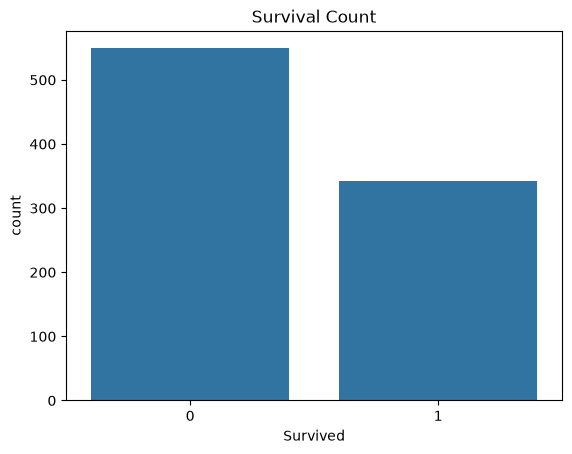

In [19]:
# now we check Univariate Analysis
sns.countplot(x="Survived", data=df)
plt.title("Survival Count")
plt.show()

In [20]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [21]:
# calculating survival rate
survival_rate = df["Survived"].value_counts(normalize=True) * 100
print(survival_rate)

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


Observation:

Most passengers did not survive compared to those who survived. The number of non-survivors is higher than survivors.

Insight:

This indicates that the survival rate on the Titanic was low, and a large number of passengers lost their lives.

Conclusion:

The majority of passengers were unable to survive the Titanic disaster.

### Q2.How many male and female passengers were there?

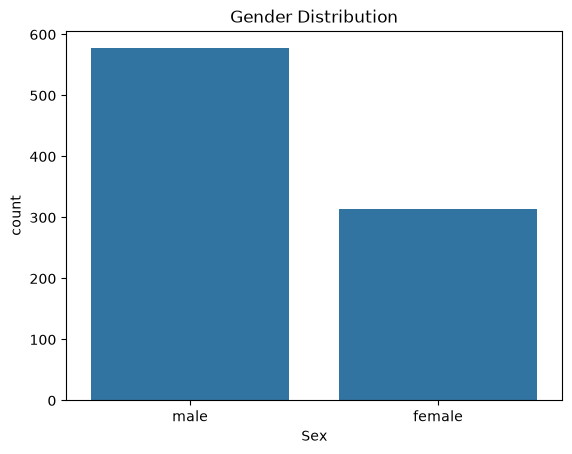

In [22]:

sns.countplot(x="Sex", data=df)
plt.title("Gender Distribution")
plt.show()

In [23]:
df['Sex'].value_counts()    

Sex
male      577
female    314
Name: count, dtype: int64

In [24]:
pd.crosstab(df["Sex"], df["Survived"], normalize="index") * 100

Survived,0,1
Sex,,
female,25.796178,74.203822
male,81.109185,18.890815


Observation:

The number of male passengers is significantly higher than female passengers.

Insight:

This shows that more males were traveling on the Titanic compared to females.

Conclusion:

Male passengers formed the majority of the dataset.

### Q3.How many passengers belonged to each class?

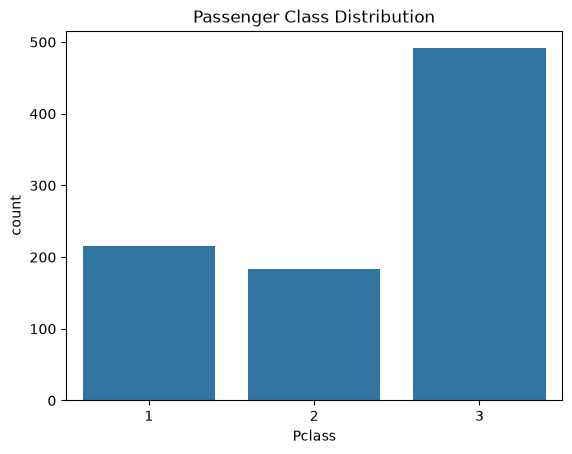

In [25]:
sns.countplot(x="Pclass", data=df)
plt.title("Passenger Class Distribution")
plt.show()

In [26]:
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Observation:

Most passengers belonged to 3rd class, followed by 1st class and then 2nd class.

Insight:

This suggests that the ship carried more lower-class passengers than upper-class passengers.

Conclusion:

Third-class passengers were the largest group on the Titanic.

### Q4.What is the age distribution of passengers?

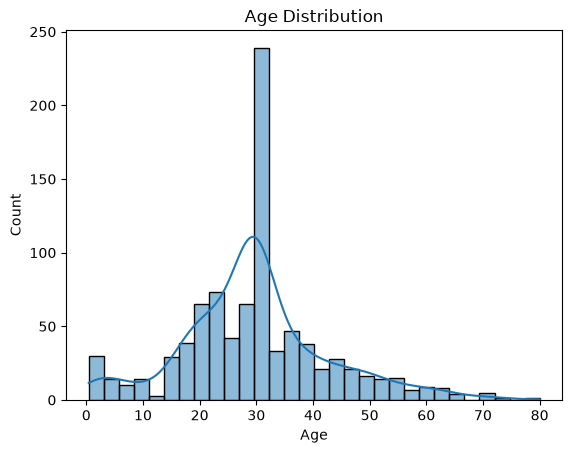

In [27]:
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution")
plt.show()

Observation:

Most passengers were young adults, mainly between 20 and 40 years of age.

Insight:

The Titanic had a higher number of working-age adults compared to children and elderly passengers.

Conclusion:

Young adults made up the largest age group among passengers.

### Q5.How was the ticket fare distributed?

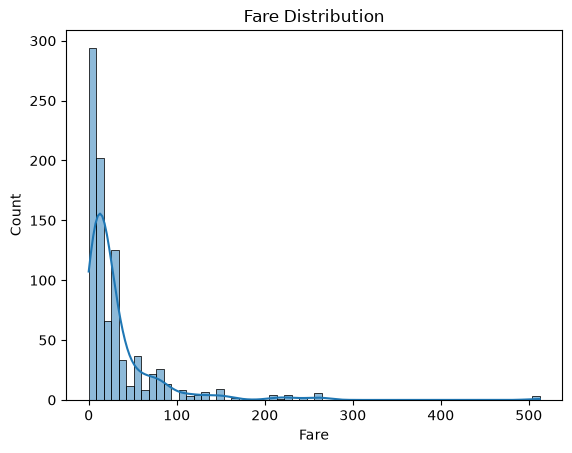

In [28]:
sns.histplot(df["Fare"], kde=True)
plt.title("Fare Distribution")
plt.show()

In [29]:
df['Fare'].value_counts()

Fare
8.0500     43
13.0000    42
7.8958     38
7.7500     34
26.0000    31
           ..
13.8583     1
50.4958     1
5.0000      1
9.8458      1
10.5167     1
Name: count, Length: 248, dtype: int64

Observation:

Most passengers paid low ticket fares, while only a few paid very high fares.

Insight:

This shows that expensive tickets were less common and mostly belonged to higher-class passengers.

Conclusion:

The fare distribution is positively skewed with a few high-value outliers.

### Q6.Which port had the highest number of passengers?

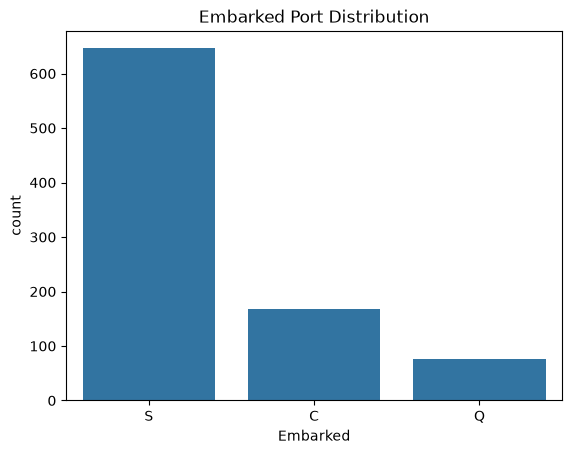

In [30]:
sns.countplot(x="Embarked", data=df)
plt.title("Embarked Port Distribution")
plt.show()

In [31]:
df['Embarked'].value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

Observation:

Most passengers boarded from port S (Southampton), followed by C (Cherbourg) and Q (Queenstown).

Insight:

Southampton was the main boarding point for Titanic passengers.

Conclusion:

The majority of passengers embarked from Southampton.

### Q7.Are there outliers in Age?

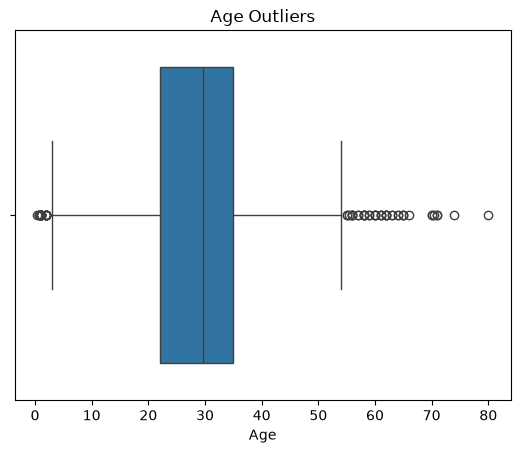

In [32]:
sns.boxplot(x=df["Age"])
plt.title("Age Outliers")
plt.show()

Observation:

Some extreme age values are present in the Age column.

Insight:

These outliers represent very young children and very old passengers.

Conclusion:

Age contains a few outliers, but they are meaningful and should not be removed without proper reason.

### Q8.Are there outliers in Fare?

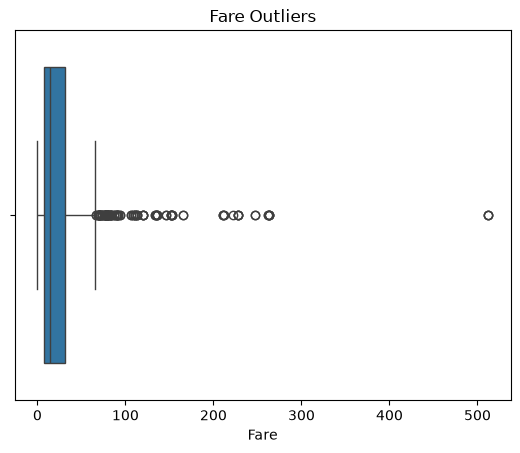

In [33]:
sns.boxplot(x=df["Fare"])
plt.title("Fare Outliers")
plt.show()

Observation:

Several passengers paid extremely high fares compared to the majority.

Insight:

These outliers likely belong to first-class passengers with luxury cabins.

Conclusion:

Fare contains significant outliers which reflect real-world passenger class differences.

# Bivariate Analysis

### Q9.Did gender affect survival chances?

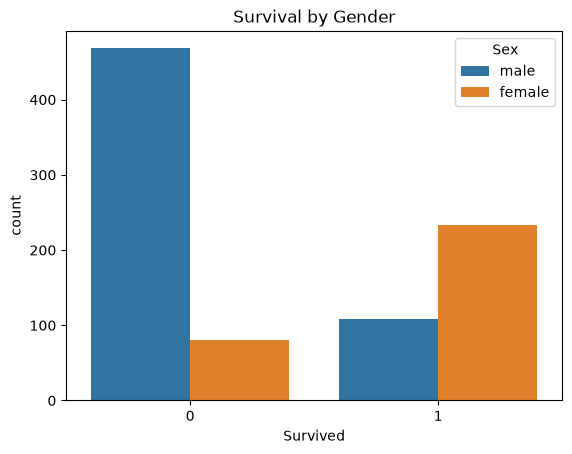

In [34]:
sns.countplot(x="Survived", hue="Sex", data=df)
plt.title("Survival by Gender")
plt.show()

Observation:

Female passengers had a much higher survival rate than male passengers.

Insight:

Women were given higher priority during rescue operations.

Conclusion:

Gender strongly affected survival chances, and females were more likely to survive.

### Q10.Did passenger class affect survival?

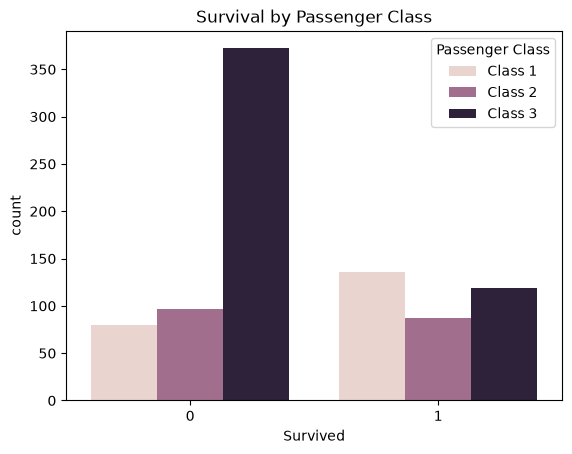

In [35]:
sns.countplot(x="Survived", hue="Pclass", data=df)
plt.title("Survival by Passenger Class")
plt.legend(title="Passenger Class", labels=["Class 1", "Class 2", "Class 3"])
plt.show()

Observation:

First-class passengers had a much higher survival rate than second and third-class passengers.

Insight:

Passengers in higher classes had better access to lifeboats and safer locations.

Conclusion:

Passenger class had a strong impact on survival.

### Q11.Did age affect survival?


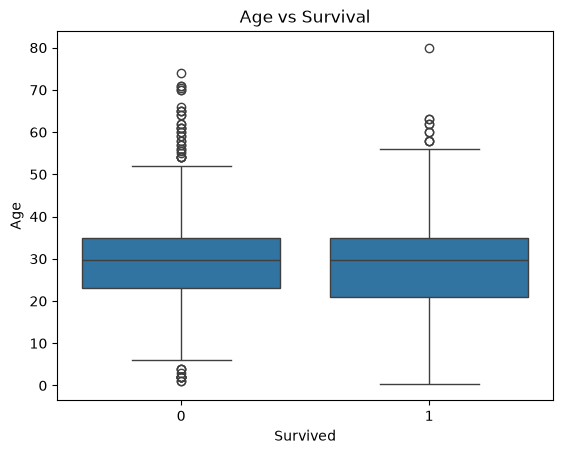

In [36]:
sns.boxplot(x="Survived", y="Age", data=df)
plt.title("Age vs Survival")
plt.show()

Observation:

Younger passengers, especially children, showed better survival compared to older passengers.

Insight:

Children may have been prioritized during rescue operations.

Conclusion:

Age had some effect on survival, especially for younger passengers.

### Q12.Did higher fare passengers survive more?

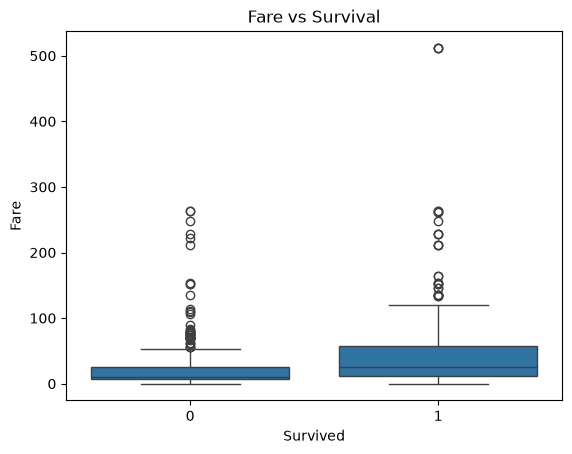

In [37]:
sns.boxplot(x="Survived", y="Fare", data=df)
plt.title("Fare vs Survival")
plt.show()

Observation:

Passengers who survived generally paid higher fares than those who did not survive.

Insight:

Higher fare often indicates higher class, which improved survival chances.

Conclusion:

Fare had a positive relationship with survival.

### Q13.Is fare related to passenger class?

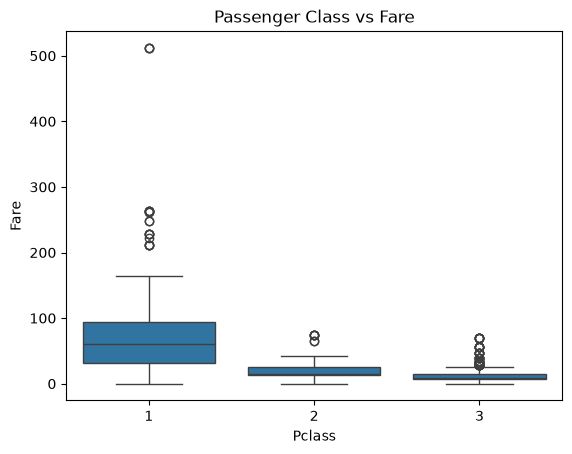

In [38]:
sns.boxplot(x="Pclass", y="Fare", data=df)
plt.title("Passenger Class vs Fare")
plt.show()

Observation:

First-class passengers paid the highest fares, while third-class passengers paid the lowest.

Insight:

There is a clear relationship between ticket fare and passenger class.

Conclusion:

Higher passenger class means higher ticket fare.

### Q14.Family Size vs Survival

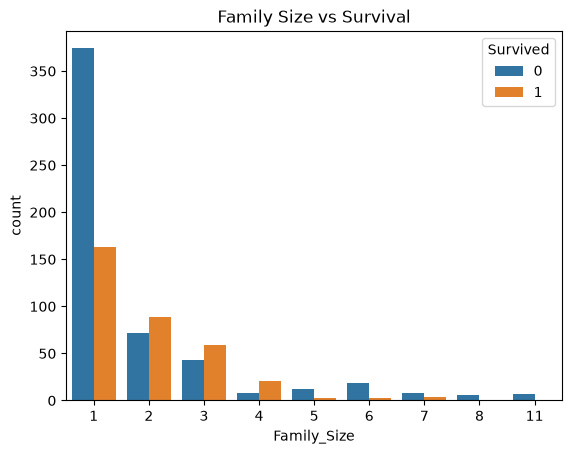

In [39]:
sns.countplot(x="Family_Size", hue="Survived", data=df)
plt.title("Family Size vs Survival")
plt.show()

Observation:

Passengers traveling with small families had better survival compared to those traveling alone or with very large families.

Insight:

A moderate family size may have provided better support during emergencies.

Conclusion:

Family size influenced survival chances.

### Q15. Which numerical features are most correlated in the dataset?

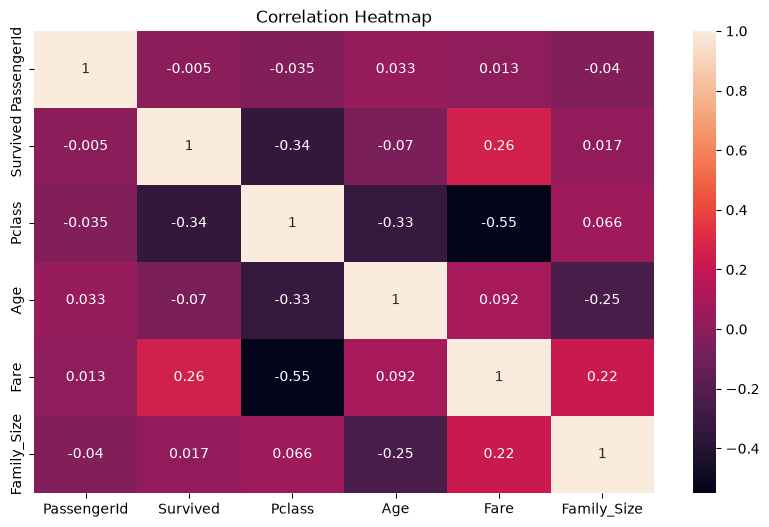

In [40]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

Observation:

Fare shows a positive correlation with survival, while Pclass shows a negative correlation with survival.

Insight:

Higher fare passengers and first-class passengers were more likely to survive.

Conclusion:

Fare and passenger class were among the strongest factors affecting survival.

### Q16. Is Fare correlated with Survival?

In [41]:
corr = df[["Fare", "Survived"]].corr()
print(corr)

              Fare  Survived
Fare      1.000000  0.257307
Survived  0.257307  1.000000


Observation:

Fare has a positive correlation with survival.

Insight:

Passengers who paid higher fares had better chances of survival.

Conclusion:

Economic status played an important role in survival.

### Q17.Is Passenger Class correlated with Survival?

In [42]:
corr = df[["Pclass", "Survived"]].corr()
print(corr)

            Pclass  Survived
Pclass    1.000000 -0.338481
Survived -0.338481  1.000000


Observation:

Pclass has a negative correlation with survival.

Insight:

Since 1st class is represented by a smaller number, lower Pclass means better survival.

Conclusion:

First-class passengers had better survival outcomes.

### Q18.Is Age correlated with Survival?

In [43]:
corr = df[["Age", "Survived"]].corr()
print(corr)

               Age  Survived
Age       1.000000 -0.069809
Survived -0.069809  1.000000


Observation:

Age has a weak negative correlation with survival.

Insight:

Younger passengers had slightly better chances of survival than older passengers.

Conclusion:

Age affected survival, but its impact was weaker compared to gender and class.

### Key Insights
1. Female passengers had the highest survival rate
2. First-class passengers survived more than lower classes
3. Higher fare passengers had better survival chances
4. Children had slightly better survival outcomes
5. Passengers with small families had better survival rates

### Conclusion
Exploratory Data Analysis of the Titanic dataset revealed that gender, passenger class, fare, and age significantly affected passenger survival. Female passengers and first-class travelers had the highest survival rates. Economic status and social class played a major role in determining survival outcomes during the Titanic disaster.

In [44]:
df.replace({"Sex": {"male": 0, "female": 1}}, inplace=True)
df.replace({"Embarked": {"S": 0, "C": 1, "Q": 2}}, inplace=True)

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,Family_Size
0,1,0,3,"Braund, Mr. Owen Harris",0,22.000000,A/5 21171,7.2500,0,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.000000,PC 17599,71.2833,1,2
2,3,1,3,"Heikkinen, Miss. Laina",1,26.000000,STON/O2. 3101282,7.9250,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.000000,113803,53.1000,0,2
4,5,0,3,"Allen, Mr. William Henry",0,35.000000,373450,8.0500,0,1
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.000000,211536,13.0000,0,1
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.000000,112053,30.0000,0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,29.699118,W./C. 6607,23.4500,0,4
889,890,1,1,"Behr, Mr. Karl Howell",0,26.000000,111369,30.0000,1,1


In [45]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,Family_Size
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,A/5 21171,7.2500,0,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,PC 17599,71.2833,1,2
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,STON/O2. 3101282,7.9250,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,113803,53.1000,0,2
4,5,0,3,"Allen, Mr. William Henry",0,35.0,373450,8.0500,0,1


# Model Development

## Introduction

After completing Exploratory Data Analysis (EDA), the next step is to build a Machine Learning model to predict passenger survival on the Titanic dataset.

The main objective of this model is to classify whether a passenger survived or not based on important features such as passenger class, gender, age, fare, family size, and embarkation port.

For this task, **Logistic Regression** is used as the classification algorithm because it is simple, interpretable, computationally efficient, and well suited for binary classification problems such as this one.

### Seperating Features and Target

In [46]:
# Features (X): all columns except identifiers and the target itself
# Target (Y): the column we want to predict
X = df.drop(columns=['PassengerId', 'Survived', 'Name', 'Ticket'])
Y = df['Survived']


The independent variables (features) were selected as:

- Pclass
- Sex
- Age
- Family_Size
- Fare
- Embarked

The dependent variable (target) was:

- Survived

Where:

- 0 = Did Not Survive
- 1 = Survived

In [47]:
print(X)

     Pclass Sex        Age     Fare Embarked  Family_Size
0         3   0  22.000000   7.2500        0            2
1         1   1  38.000000  71.2833        1            2
2         3   1  26.000000   7.9250        0            1
3         1   1  35.000000  53.1000        0            2
4         3   0  35.000000   8.0500        0            1
..      ...  ..        ...      ...      ...          ...
886       2   0  27.000000  13.0000        0            1
887       1   1  19.000000  30.0000        0            1
888       3   1  29.699118  23.4500        0            4
889       1   0  26.000000  30.0000        1            1
890       3   0  32.000000   7.7500        2            1

[891 rows x 6 columns]


In [48]:
print(Y)

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64


In [49]:
# Split the data into training (80%) and testing (20%) sets
# stratify=Y keeps the same survival ratio in both train and test sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=2, stratify=Y
)


In [50]:
print(X.shape, X_train.shape, X_test.shape)

(891, 6) (712, 6) (179, 6)


The dataset was divided into two parts:

- Training Data = 80%
- Testing Data = 20%

The training data was used to train the model, while the testing data was used to evaluate model performance.

This helps in checking how well the model performs on unseen data.

# Model Trainning

### Logistic Regression

In [51]:
# Initialize the Logistic Regression model
# max_iter increased to ensure convergence
model = LogisticRegression(max_iter=1000)


In [52]:
# training the logistic regression model with the training data
model.fit(X_train, Y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

A Logistic Regression model was created and trained using the training dataset.

The model learned patterns from the passenger data and used those patterns to predict survival outcomes.

This step is called model fitting.

### Model Evaluation

### Accuracy Score

In [53]:
# accuracy on training data
X_train_prediction = model.predict(X_train)

In [54]:
print(X_train_prediction)

[0 0 1 0 1 1 1 0 1 1 0 1 1 1 1 0 0 1 0 1 0 1 0 0 1 0 0 1 0 0 1 0 1 0 0 1 1
 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 1 0 1 0 1 0 0 0 0 0 1 0 0 1 1 1 0 0 0 0 1
 1 0 1 0 1 0 0 0 1 1 0 0 1 1 1 1 0 0 1 1 0 0 1 1 1 1 1 0 0 0 0 0 0 1 0 0 1
 0 0 1 1 0 0 1 0 1 0 0 1 1 0 1 1 0 1 0 0 1 1 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0
 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 1 1 0 1 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0
 0 0 0 0 1 0 0 1 0 1 0 1 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 1 1 0 0 1 1 0 0 0 0
 0 0 0 0 0 0 1 0 0 1 1 1 0 1 0 1 0 0 0 1 1 1 1 0 0 0 0 1 0 0 0 1 0 1 1 0 0
 0 0 1 0 1 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 1 0 1 1 1 1 0 0 1 0
 0 0 1 0 0 1 0 1 1 1 1 0 1 0 1 0 1 1 0 0 0 0 0 0 0 1 0 0 1 1 0 0 1 0 0 0 0
 0 0 0 1 0 1 0 0 0 1 0 1 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0 1 0 1 1 0 0 1 0 1 0
 0 1 1 0 0 1 1 0 0 0 0 0 1 0 0 0 1 0 1 1 1 1 1 0 0 0 0 1 0 1 1 0 0 1 0 1 0
 1 0 1 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0 1 0 0 1 1 0 1 0 1 0 0 0 1 0 0 0
 0 0 0 0 1 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 1 1 0 0 0 0 0 0 1 0 1 1
 1 0 1 0 1 0 0 1 0 1 0 1 

In [55]:
train_data_accuracy = accuracy_score(Y_train, X_train_prediction)
print("Accuracy on training data:", train_data_accuracy)

Accuracy on training data: 0.8019662921348315


In [56]:
# accuracy on test data
X_test_prediction = model.predict(X_test)

In [57]:
print(X_test_prediction)

[0 0 0 0 1 0 1 1 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 1 1 0 0 1 1 0 0 1 1 1 0 1 0
 0 0 0 0 1 0 1 1 1 0 0 0 1 0 0 1 0 1 1 1 0 0 0 0 0 1 0 1 1 0 0 1 0 1 0 1 0
 1 0 1 0 0 1 1 1 1 0 0 0 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 1 0 1 0 1 0 1 0 0 0
 0 0 1 1 0 1 1 1 1 0 0 0 1 1 0 0 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 1 0 1
 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 1 1 0 0 1 0 1 1 0 0 0 0 0 0 0 0]


In [58]:
test_data_accuracy = accuracy_score(Y_test, X_test_prediction)
print("Accuracy on test data:", test_data_accuracy)

Accuracy on test data: 0.7877094972067039


## Model Accuracy Analysis

The Logistic Regression model showed good performance in predicting passenger survival on the Titanic dataset.

The model achieved approximately 80% accuracy on one evaluation and 78% accuracy on another evaluation.

This means that the model correctly predicted passenger survival for most cases.

The small difference between 80% and 78% indicates that the model is performing consistently and is not heavily overfitting.

This also shows that important features such as gender, passenger class, age, and fare played a strong role in predicting survival.

Overall, the model performance is considered good for a binary classification problem like Titanic Survival Prediction.

### Confusion Matrix

While accuracy gives an overall sense of performance, it doesn't show *where* the model is making mistakes. A confusion matrix breaks predictions down into true positives, true negatives, false positives, and false negatives, helping us understand the model's behavior more precisely.

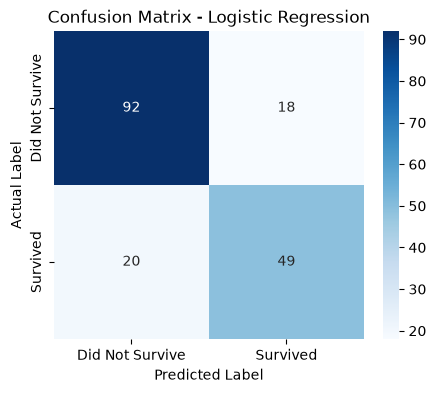

In [59]:
# Generate and visualize the confusion matrix for the test set predictions
cm = confusion_matrix(Y_test, X_test_prediction)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Did Not Survive", "Survived"],
            yticklabels=["Did Not Survive", "Survived"])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

Observation:

The diagonal cells (top-left and bottom-right) represent correct predictions, while the off-diagonal cells represent misclassifications. A higher concentration of values along the diagonal indicates stronger model performance.

### Classification Report

The classification report provides a more detailed breakdown of model performance for each class, including precision, recall, and F1-score, in addition to accuracy.

In [60]:
# Detailed classification metrics: precision, recall, F1-score for each class
print(classification_report(Y_test, X_test_prediction, target_names=["Did Not Survive", "Survived"]))

                 precision    recall  f1-score   support

Did Not Survive       0.82      0.84      0.83       110
       Survived       0.73      0.71      0.72        69

       accuracy                           0.79       179
      macro avg       0.78      0.77      0.77       179
   weighted avg       0.79      0.79      0.79       179



Observation:

- **Precision** tells us, out of all passengers the model predicted as survivors, how many actually survived.
- **Recall** tells us, out of all passengers who actually survived, how many the model correctly identified.
- **F1-score** balances precision and recall into a single metric, which is especially useful when classes are not perfectly balanced.

Together with the confusion matrix, these metrics give a fuller picture of model performance beyond a single accuracy number.